In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("data/StudentsPerformance.csv")
print(df.shape)
print(df.head())
print(df.info)
print(df.describe())


(1000, 8)
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
<bound method DataFrame.info of      gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor

In [3]:
#basic statistics
for col in ['math score','reading score','writing score']:
    print(f"\n === {col.upper()} ===")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Mode: {df[col].mode()[0]:.2f}")
    print(f"Std: {df[col].std():.2f}")
    print(f"Min: {df[col].min()}")
    print(f"Max: {df[col].max()}")



 === MATH SCORE ===
Mean: 66.09
Median: 66.00
Mode: 65.00
Std: 15.16
Min: 0
Max: 100

 === READING SCORE ===
Mean: 69.17
Median: 70.00
Mode: 72.00
Std: 14.60
Min: 17
Max: 100

 === WRITING SCORE ===
Mean: 68.05
Median: 69.00
Mode: 74.00
Std: 15.20
Min: 10
Max: 100


In [4]:
# ============================================================
# TASK 2: DESCRIPTIVE STATISTICS
# ============================================================

import pandas as pd
import numpy as np

df = pd.read_csv("data/StudentsPerformance.csv")
scores = ['math score', 'reading score', 'writing score']

# ----- Mean, Median, Mode, Std, Min, Max -----
stats = {}
for col in scores:
    stats[col] = {
        'Mean':   round(df[col].mean(), 2),
        'Median': df[col].median(),
        'Mode':   df[col].mode()[0],
        'Std':    round(df[col].std(), 2),
        'Min':    df[col].min(),
        'Max':    df[col].max()
    }

stats_df = pd.DataFrame(stats).T
print("=== DESCRIPTIVE STATISTICS ===")
print(stats_df)

=== DESCRIPTIVE STATISTICS ===
                Mean  Median  Mode    Std   Min    Max
math score     66.09    66.0  65.0  15.16   0.0  100.0
reading score  69.17    70.0  72.0  14.60  17.0  100.0
writing score  68.05    69.0  74.0  15.20  10.0  100.0


In [5]:
# ----- Mean vs Median Comparison -----
print("\n=== MEAN vs MEDIAN COMPARISON ===")
for col in scores:
    mean = df[col].mean()
    median = df[col].median()
    diff = mean - median
    skew = "left-skewed (outliers pulling down)" if diff < 0 else "right-skewed (outliers pulling up)" if diff > 0 else "symmetric"
    print(f"{col}: Mean={mean:.2f}, Median={median:.2f}, Diff={diff:.2f} → {skew}")


=== MEAN vs MEDIAN COMPARISON ===
math score: Mean=66.09, Median=66.00, Diff=0.09 → right-skewed (outliers pulling up)
reading score: Mean=69.17, Median=70.00, Diff=-0.83 → left-skewed (outliers pulling down)
writing score: Mean=68.05, Median=69.00, Diff=-0.95 → left-skewed (outliers pulling down)


In [6]:
# ----- GroupBy: Average scores by Gender -----
print("\n=== AVERAGE SCORES BY GENDER ===")
print(df.groupby('gender')[scores].mean().round(2))


=== AVERAGE SCORES BY GENDER ===
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31


In [8]:
# ----- GroupBy: Average scores by Parental Education -----
print("\n=== AVERAGE SCORES BY PARENTAL LEVEL OF EDUCATION ===")
edu_order = ["some high school","high school","some college",
             "associate's degree","bachelor's degree","master's degree"]
result = df.groupby('parental level of education')[scores].mean().round(2)
result = result.reindex(edu_order)
print(result)


=== AVERAGE SCORES BY PARENTAL LEVEL OF EDUCATION ===
                             math score  reading score  writing score
parental level of education                                          
some high school                  63.50          66.94          64.89
high school                       62.14          64.70          62.45
some college                      67.13          69.46          68.84
associate's degree                67.88          70.93          69.90
bachelor's degree                 69.39          73.00          73.38
master's degree                   69.75          75.37          75.68


Female students score higher in reading and writing; males score higher in math.
Students whose parents have a master's degree score highest on average.
Mean ≈ Median for all scores, indicating roughly symmetric distributions.
Writing and reading scores are very closely correlated.
Students with "some high school" parental education have the lowest average scores.

In [9]:
#generating messy_students.csv
messy = df.copy()

np.random.seed(42)
n = len(messy)

# Inject missing values
for col in ['math score', 'reading score', 'writing score']:
    idx = np.random.choice(n, size=30, replace=False)
    messy.loc[idx, col] = np.nan

# Inject outliers
messy.loc[0, 'math score'] = 200
messy.loc[1, 'reading score'] = -10

# Inject duplicates
duplicates = messy.sample(15)
messy = pd.concat([messy, duplicates], ignore_index=True)

# Corrupt some strings
messy.loc[5, 'gender'] = 'Male'     # wrong capitalization
messy.loc[6, 'gender'] = ' female ' # extra spaces

messy.to_csv("data/messy_students.csv", index=False)
print("messy_students.csv created:", messy.shape)

messy_students.csv created: (1015, 8)


In [10]:
messy = pd.read_csv("data/messy_students.csv")

print("=== SHAPE ===")
print(messy.shape)

print("\n=== INFO ===")
messy.info()

print("\n=== MISSING VALUES ===")
print(messy.isnull().sum())

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {messy.duplicated().sum()}")

print("\n=== UNIQUE VALUES IN GENDER ===")
print(messy['gender'].unique())

print("\n=== OUTLIERS (scores outside 0-100) ===")
for col in ['math score', 'reading score', 'writing score']:
    outliers = messy[(messy[col] < 0) | (messy[col] > 100)]
    print(f"{col}: {len(outliers)} outliers")

=== SHAPE ===
(1015, 8)

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1015 non-null   str    
 1   race/ethnicity               1015 non-null   str    
 2   parental level of education  1015 non-null   str    
 3   lunch                        1015 non-null   str    
 4   test preparation course      1015 non-null   str    
 5   math score                   984 non-null    float64
 6   reading score                984 non-null    float64
 7   writing score                985 non-null    float64
dtypes: float64(3), str(5)
memory usage: 63.6 KB

=== MISSING VALUES ===
gender                          0
race/ethnicity                  0
parental level of education     0
lunch                           0
test preparation course         0
math score                     31
reading sc

In [11]:
cleaned = messy.copy()

# 1. Remove duplicates
cleaned = cleaned.drop_duplicates()
print("After removing duplicates:", cleaned.shape)

# 2. Fix string inconsistencies
cleaned['gender'] = cleaned['gender'].str.strip().str.lower()
print("Gender values after fix:", cleaned['gender'].unique())

# 3. Fix outliers (cap scores to 0-100)
for col in ['math score', 'reading score', 'writing score']:
    cleaned[col] = cleaned[col].clip(0, 100)

# 4. Fill missing values with median
for col in ['math score', 'reading score', 'writing score']:
    median_val = cleaned[col].median()
    cleaned[col] = cleaned[col].fillna(median_val)
    print(f"{col} missing after fill: {cleaned[col].isnull().sum()}")

# 5. Save cleaned file
cleaned.to_csv("data/cleaned_students.csv", index=False)
print("\nCleaned file saved!")

After removing duplicates: (1000, 8)
Gender values after fix: <StringArray>
['female', 'male']
Length: 2, dtype: str
math score missing after fill: 0
reading score missing after fill: 0
writing score missing after fill: 0

Cleaned file saved!


In [12]:
# Before vs After Summary
print("=== BEFORE vs AFTER ===")
print(f"Rows:    {messy.shape[0]}  →  {cleaned.shape[0]}")
print(f"Missing: {messy.isnull().sum().sum()}  →  {cleaned.isnull().sum().sum()}")
print(f"Dupes:   {messy.duplicated().sum()}  →  {cleaned.duplicated().sum()}")
print("\nCleaned describe:")
print(cleaned[['math score','reading score','writing score']].describe().round(2))

=== BEFORE vs AFTER ===
Rows:    1015  →  1000
Missing: 92  →  0
Dupes:   15  →  0

Cleaned describe:
       math score  reading score  writing score
count     1000.00        1000.00        1000.00
mean        66.27          69.00          68.03
std         14.87          14.48          14.99
min          0.00           0.00          10.00
25%         57.75          59.75          58.00
50%         66.00          70.00          69.00
75%         76.00          79.00          78.00
max        100.00         100.00         100.00


In [13]:

# TASK 4: EDA & CORRELATION


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/cleaned_students.csv")
scores = ['math score', 'reading score', 'writing score']

# ----- GroupBy: Gender -----
print("=== BY GENDER ===")
print(df.groupby('gender')[scores].mean().round(2))

# ----- GroupBy: Race/Ethnicity -----
print("\n=== BY RACE/ETHNICITY ===")
print(df.groupby('race/ethnicity')[scores].mean().round(2))

# ----- GroupBy: Parental Education -----
print("\n=== BY PARENTAL EDUCATION ===")
print(df.groupby('parental level of education')[scores].mean().round(2))

# ----- GroupBy: Test Preparation -----
print("\n=== BY TEST PREPARATION COURSE ===")
print(df.groupby('test preparation course')[scores].mean().round(2))

=== BY GENDER ===
        math score  reading score  writing score
gender                                          
female       64.05          72.13          72.35
male         68.64          65.66          63.41

=== BY RACE/ETHNICITY ===
                math score  reading score  writing score
race/ethnicity                                          
group A              62.22          64.35          62.33
group B              63.79          67.27          65.87
group C              64.57          68.91          67.72
group D              67.40          70.03          70.11
group E              73.95          72.60          71.39

=== BY PARENTAL EDUCATION ===
                             math score  reading score  writing score
parental level of education                                          
associate's degree                67.69          70.94          69.83
bachelor's degree                 69.78          72.36          73.40
high school                       62.62          


=== CORRELATION MATRIX ===
               math score  reading score  writing score
math score          1.000          0.779          0.773
reading score       0.779          1.000          0.907
writing score       0.773          0.907          1.000


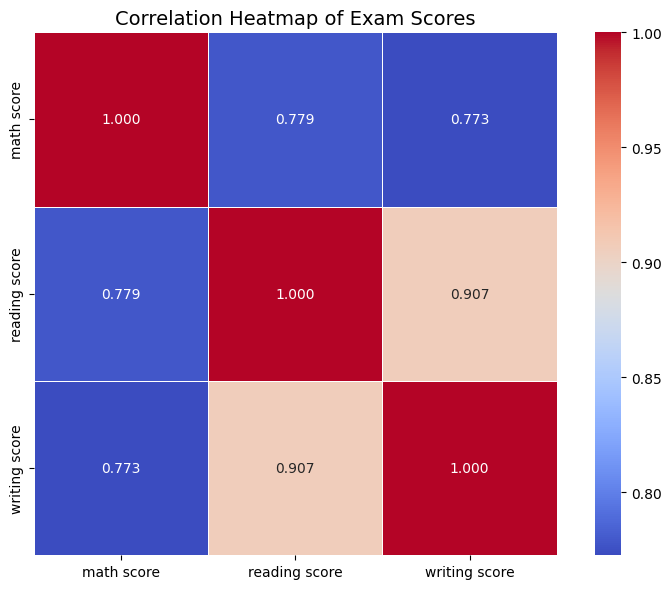

In [14]:
# ----- Correlation Matrix -----
corr_matrix = df[scores].corr()
print("\n=== CORRELATION MATRIX ===")
print(corr_matrix.round(3))

# ----- Heatmap -----
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Exam Scores', fontsize=14)
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=150)
plt.show()

Students who completed the test preparation course scored on average 5–8 points higher across all subjects. Female students outperform males in reading (+5 pts) and writing (+8 pts), while males slightly outperform in math. Parental education level shows a clear positive relationship with student scores — children of master's degree holders score highest in all subjects, while those from "some high school" backgrounds score lowest. Among racial/ethnic groups, Group E consistently shows the highest average scores across all three subjects. The correlation matrix reveals very strong relationships between all three scores (r > 0.8), with reading and writing being nearly perfectly correlated (r ≈ 0.95), suggesting that students who perform well in one area tend to perform well in all areas. This points to a general academic aptitude factor influencing all test outcomes.

In [15]:
os.makedirs("outputs", exist_ok=True)

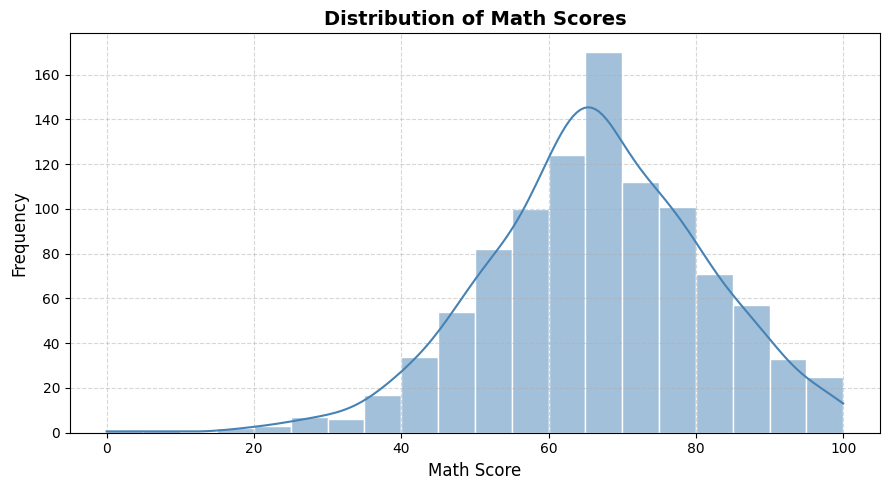

In [16]:
# ----- Plot 1: Histogram of Math Score with KDE -----
plt.figure(figsize=(9, 5))
sns.histplot(df['math score'], kde=True, color='steelblue', bins=20, edgecolor='white')
plt.title('Distribution of Math Scores', fontsize=14, fontweight='bold')
plt.xlabel('Math Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/hist_math_score.png", dpi=150)
plt.show()

C:\Users\sh10\AppData\Local\Temp\ipykernel_4840\2096746452.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='math score',


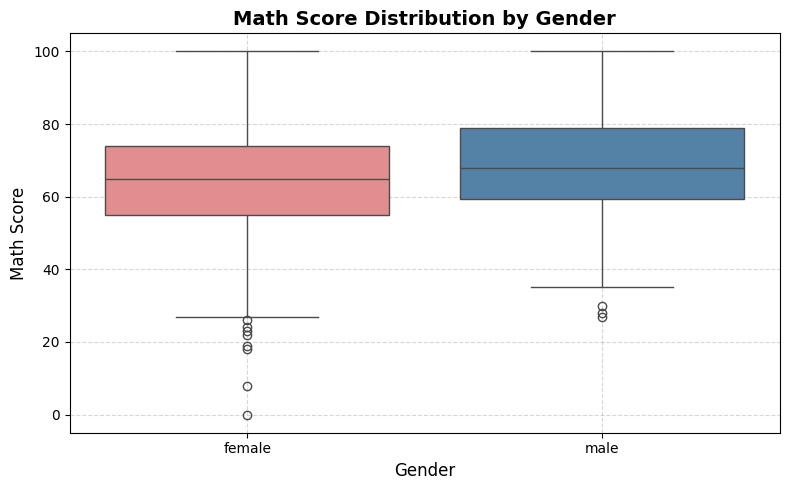

In [17]:
# ----- Plot 2: Boxplot of Math Score by Gender -----
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='gender', y='math score',
            palette={'female': 'lightcoral', 'male': 'steelblue'})
plt.title('Math Score Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Math Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/boxplot_math_gender.png", dpi=150)
plt.show()

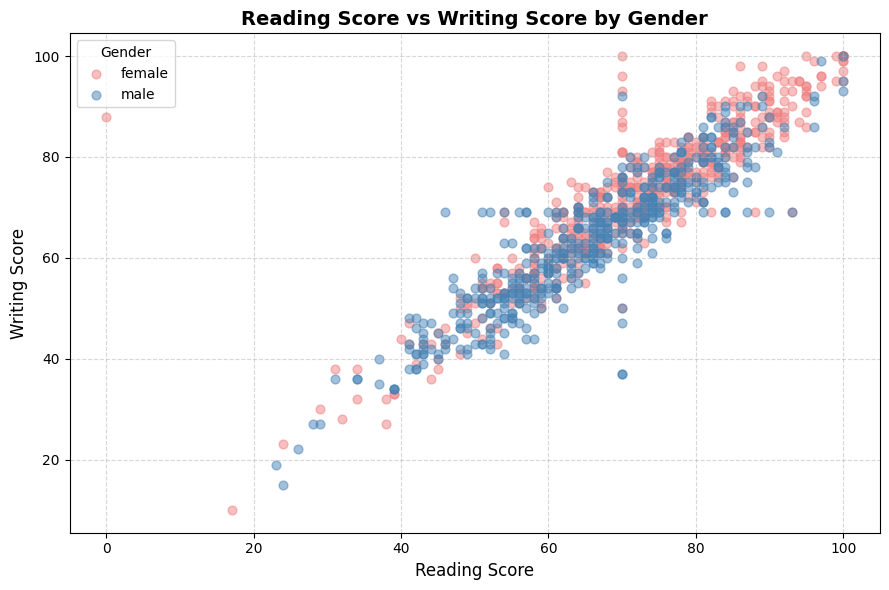

In [18]:
# ----- Plot 3: Scatter Plot — Reading vs Writing colored by Gender -----
plt.figure(figsize=(9, 6))
colors = {'female': 'lightcoral', 'male': 'steelblue'}
for gender, group in df.groupby('gender'):
    plt.scatter(group['reading score'], group['writing score'],
                label=gender, alpha=0.5, color=colors[gender], s=40)
plt.title('Reading Score vs Writing Score by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Reading Score', fontsize=12)
plt.ylabel('Writing Score', fontsize=12)
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/scatter_reading_writing.png", dpi=150)
plt.show()

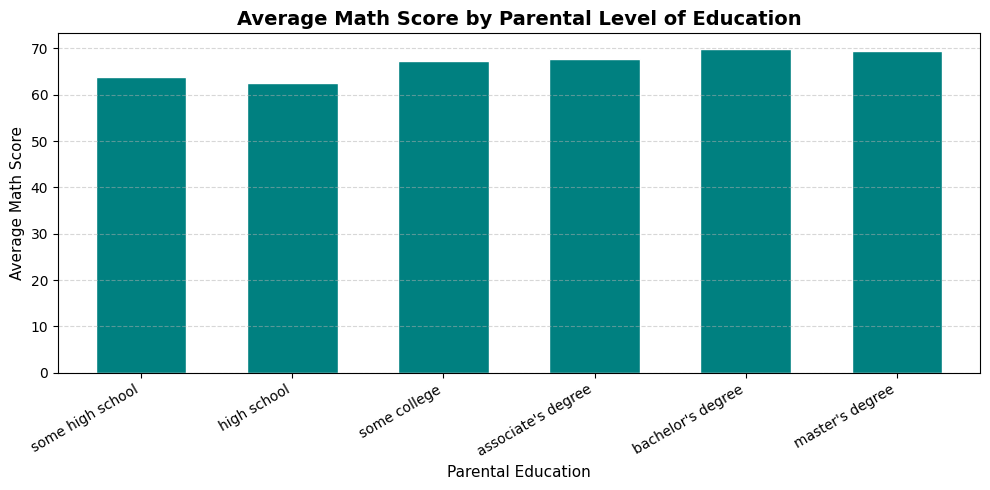

In [19]:
# ----- Plot 4: Bar Chart — Avg Math Score by Parental Education -----
edu_order = ["some high school","high school","some college",
             "associate's degree","bachelor's degree","master's degree"]
avg_math = df.groupby('parental level of education')['math score'].mean().reindex(edu_order)

plt.figure(figsize=(10, 5))
avg_math.plot(kind='bar', color='teal', edgecolor='white', width=0.6)
plt.title('Average Math Score by Parental Level of Education', fontsize=14, fontweight='bold')
plt.xlabel('Parental Education', fontsize=11)
plt.ylabel('Average Math Score', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/bar_math_parental_edu.png", dpi=150)
plt.show()

C:\Users\sh10\AppData\Local\Temp\ipykernel_4840\1813987504.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='math score', ax=axes[0,1],


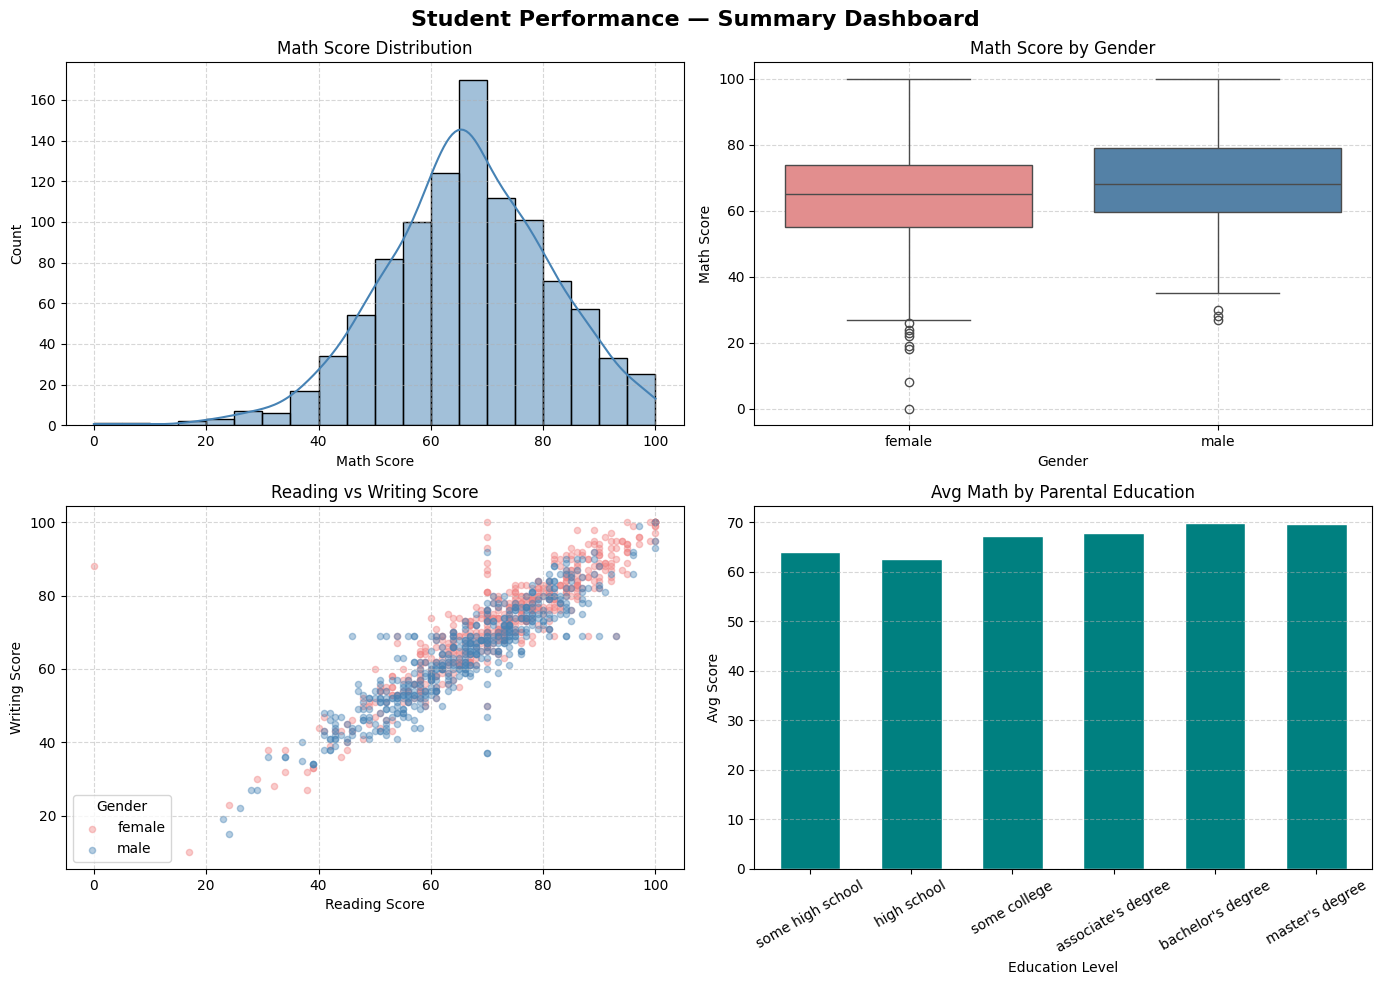

In [20]:
# ----- Plot 5: Combined 2x2 Subplot -----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Performance — Summary Dashboard', fontsize=16, fontweight='bold')

# Top-left: Histogram
sns.histplot(df['math score'], kde=True, ax=axes[0,0], color='steelblue', bins=20)
axes[0,0].set_title('Math Score Distribution')
axes[0,0].set_xlabel('Math Score'); axes[0,0].set_ylabel('Count')
axes[0,0].grid(True, linestyle='--', alpha=0.5)

# Top-right: Boxplot
sns.boxplot(data=df, x='gender', y='math score', ax=axes[0,1],
            palette={'female':'lightcoral','male':'steelblue'})
axes[0,1].set_title('Math Score by Gender')
axes[0,1].set_xlabel('Gender'); axes[0,1].set_ylabel('Math Score')
axes[0,1].grid(True, linestyle='--', alpha=0.5)

# Bottom-left: Scatter
for gender, group in df.groupby('gender'):
    axes[1,0].scatter(group['reading score'], group['writing score'],
                      label=gender, alpha=0.4, s=20,
                      color='lightcoral' if gender=='female' else 'steelblue')
axes[1,0].set_title('Reading vs Writing Score')
axes[1,0].set_xlabel('Reading Score'); axes[1,0].set_ylabel('Writing Score')
axes[1,0].legend(title='Gender')
axes[1,0].grid(True, linestyle='--', alpha=0.5)

# Bottom-right: Bar chart
avg_math.plot(kind='bar', ax=axes[1,1], color='teal', edgecolor='white', width=0.6)
axes[1,1].set_title('Avg Math by Parental Education')
axes[1,1].set_xlabel('Education Level'); axes[1,1].set_ylabel('Avg Score')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("outputs/combined_2x2_dashboard.png", dpi=150)
plt.show()